In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    #t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(2*t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

def choose_splitter(nparray, split_method):
    if split_method == 'even_odd':
        return split_by_even_odd(nparray)
    elif split_method == 'first_second':
        return split_in_two(nparray)
    else:
        raise ValueError(f"Unknown split type: {split_method}")
    

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    m = min(len(even), len(odd))
    even, odd = even[:m], odd[:m]
    return even, odd


# Define how populations evolve
def simulate(parameters, observation, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    #t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics but add noise: intended for our actual observation
def add_noise_and_plot(simulation_result, distn, sigma_hare, sigma_lynx, time):

    if distn == 'none':
        pass
    elif distn == 'gaussian':
        noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=simulation_result.shape)
        simulation_result = simulation_result + noise
    elif distn == 'poisson':
        lam = np.clip(simulation_result, 1e-6, None)
        simulation_result = np.random.poisson(lam)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")

    plot_observed_data(time,simulation_result)

    
    return simulation_result

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation, t_span):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation,t_span)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    latent = simulate_match_data(parameters, n_obs,observation, t_span)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation, t_span):
    latent = simulate_match_data(parameters, n_obs, observation, t_span)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation,t_span)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation, t_span)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.13,   # alpha - 1.6 old: 0.1
        0.015,   # beta - 3.2 old: 0.02
        0.008,  # delta - 0.6
        0.12    # gamma - 0.56
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3])

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 24
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation, t_span)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation, t_span):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation, t_span)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


In [25]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.005, 0.05], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior_mcmc, posterior_direct, inference

In [26]:
'''

results = {
        "samples1": samples1,          # posterior samples (1000, 4)
        "samples2": samples2,          # posterior samples (1000, 4)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior1": prior1,
        "prior2": prior2,
        "theta1": theta1,              # simulated θ used for training (10000, 4)
        "theta2": theta2,              # simulated θ used for training (10000, 4)
        "x1": x1,                      # simulated summaries (10000, 4)
        "x2": x2,                      # simulated summaries (10000, 4)
        "x_obs1": x_obs1,              # observed summary (4,)
        "x_obs2": x_obs2,              # observed summary (4,)
        "time_vec1": time1,        # years
        "time_vec2": time2,        # years
        "obs1": obs1,  # raw data (n_obs, 2)
        "obs2": obs2,  # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise1": noise1,        # 'none' / 'gaussian' / 'poisson'
        "noise2": noise2,        # 'none' / 'gaussian' / 'poisson'
        "n_obs1": n_obs1,
        "n_obs2": n_obs2,
        "sigma_hare1": sigma_hare1,
        "sigma_lynx1": sigma_lynx1,
        "sigma_hare2": sigma_hare2,
        "sigma_lynx2": sigma_lynx2,
        "split_type": split_type,
        "t_span": t_span
    }

fname = f"CALIBRATION TESTER_split_{split_type}_results_{prior_name}_{noise1}.pt"
torch.save(results, fname)

'''

'\n\nresults = {\n        "samples1": samples1,          # posterior samples (1000, 4)\n        "samples2": samples2,          # posterior samples (1000, 4)\n        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)\n        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)\n        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)\n        "inference1": inference1,      # NPE object\n        "inference2": inference2,      # NPE object\n        "prior1": prior1,\n        "prior2": prior2,\n        "theta1": theta1,              # simulated θ used for training (10000, 4)\n        "theta2": theta2,              # simulated θ used for training (10000, 4)\n        "x1": x1,                      # simulated summaries (10000, 4)\n        "x2": x2,                      # simulated 

In [27]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior1", "prior2",
        "theta1", "theta2",
        "x1", "x2",
        "x_obs1", "x_obs2",
        "time_vec1", "time_vec2",
        "obs1", "obs2",
        "prior_name",
        "noise1", "noise2",
        "n_obs1", "n_obs2",
        "sigma_hare1", "sigma_lynx1",
        "sigma_hare2", "sigma_lynx2",
        "split_type", "t_span", "true_parameters"
    ]

    # update to include t_span when we retrain models

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [28]:
fname1 = "CALIBRATION TESTER_split_even_odd_results_uniform_poisson.pt"
fname2 = "CALIBRATION TESTER_split_first_second_results_uniform_poisson.pt"
fname3 = "CALIBRATION TESTER_split_even_odd_results_logn_poisson.pt"
fname4 = "CALIBRATION TESTER_split_first_second_results_logn_poisson.pt"

fname5 = "CALIBRATION TESTER_split_even_odd_results_logn_poisson_1000EPOCH.pt"
fname6 = "CALIBRATION TESTER_split_first_second_results_logn_poisson_1000EPOCH.pt"

# === CHANGE (2026-05-06): new same-noise training files. Saved by the
# updated LV_KL_Calibrate notebook with `noise = 'gaussian'` (or whatever
# shared training noise was used). Both splits are trained on identical
# null-noise simulations; the systematic is injected only at test time.
# ===
fname_eo_gauss = "CALIBRATION TESTER_split_even_odd_results_logn_gaussian_SAMENOISE_1000EPOCH.pt"
fname_fs_gauss = "CALIBRATION TESTER_split_first_second_results_logn_gaussian_SAMENOISE_1000EPOCH.pt"

# Pick whichever file you want to test; default to the new same-noise gaussian run.
res = load_results_file(fname_fs_gauss)  # change to fname_eo_gauss / fname_fs_gauss after retraining
# update to include t_span when we retrain models
# update to include true_params if needed but think first
(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior1, prior2,
 theta1, theta2,
 x1, x2,
 x_obs1, x_obs2,
 time1, time2,
 obs1, obs2,
 prior_name,
 noise1, noise2,
 n_obs1, n_obs2,
 sigma_hare1, sigma_lynx1,
 sigma_hare2, sigma_lynx2,
 split_type, t_span, true_parameters) = extract_results(res)

# === CHANGE (2026-05-06): expose a single `noise_train` alias.
# Under the new methodology, noise1 == noise2 == training noise. We use
# `noise_train` everywhere downstream so it is unambiguous.
# Backwards-compat: if results dict has the new "noise" key, use it; else
# fall back to noise1 (which equalled noise2 in any sane saved file).
noise_train = res.get("noise", noise1)
assert noise1 == noise2, (
    "Loaded result has different noise on each split — that is the OLD "
    "(incorrect) regime. Retrain with the updated LV_KL_Calibrate."
)


/tmp/ipykernel_2728590/1040296050.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


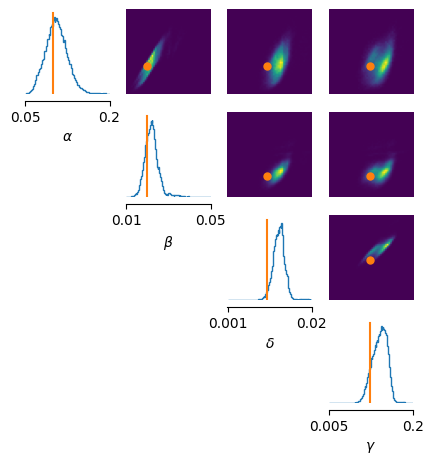

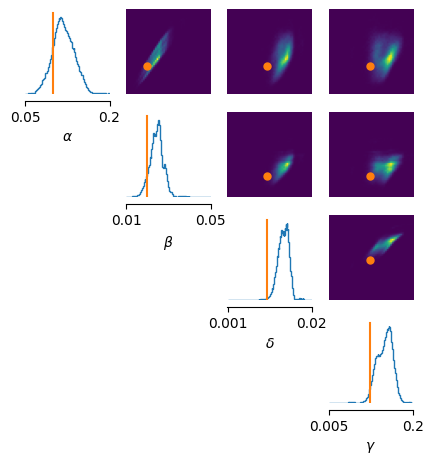

In [5]:

_ = pairplot(
            samples1,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
_ = pairplot(
            samples2,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

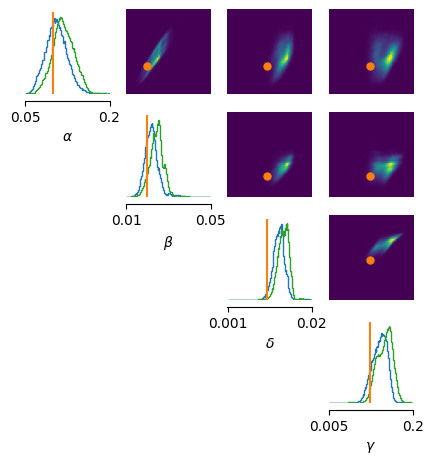

In [6]:
# overlay posteriors

_ = pairplot(
    [samples1, samples2],                       
    points=true_parameters[None, :],
    limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
    ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
    figsize=(5, 5),
    labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
)

#### Better pairplots (Will's Apr-9 / Apr-14 asks)

Prior shrinkage and split-1 vs split-2 overlays in both `sbi.pairplot` and `getdist` flavours. (No Fisher panel — the LV ODE has no closed-form score.)


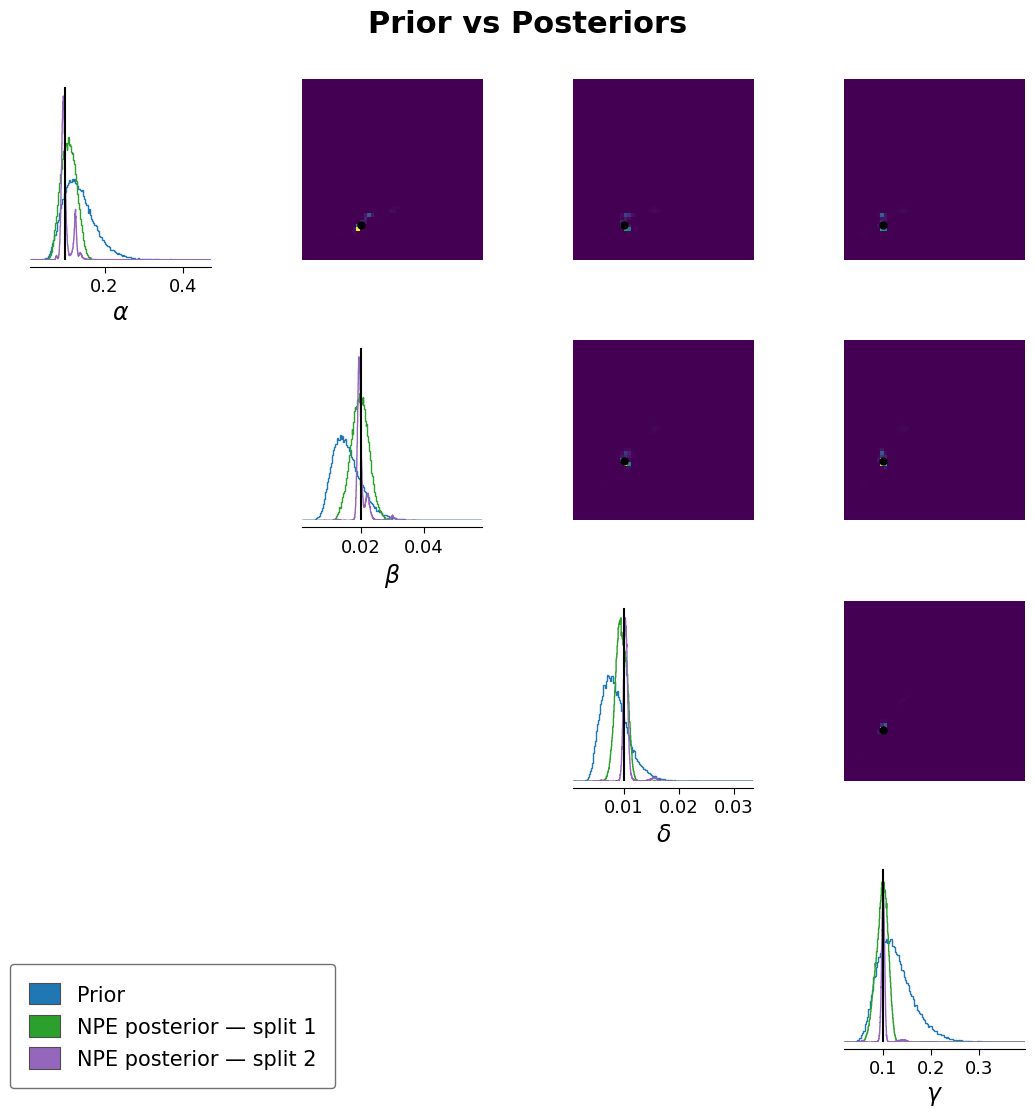

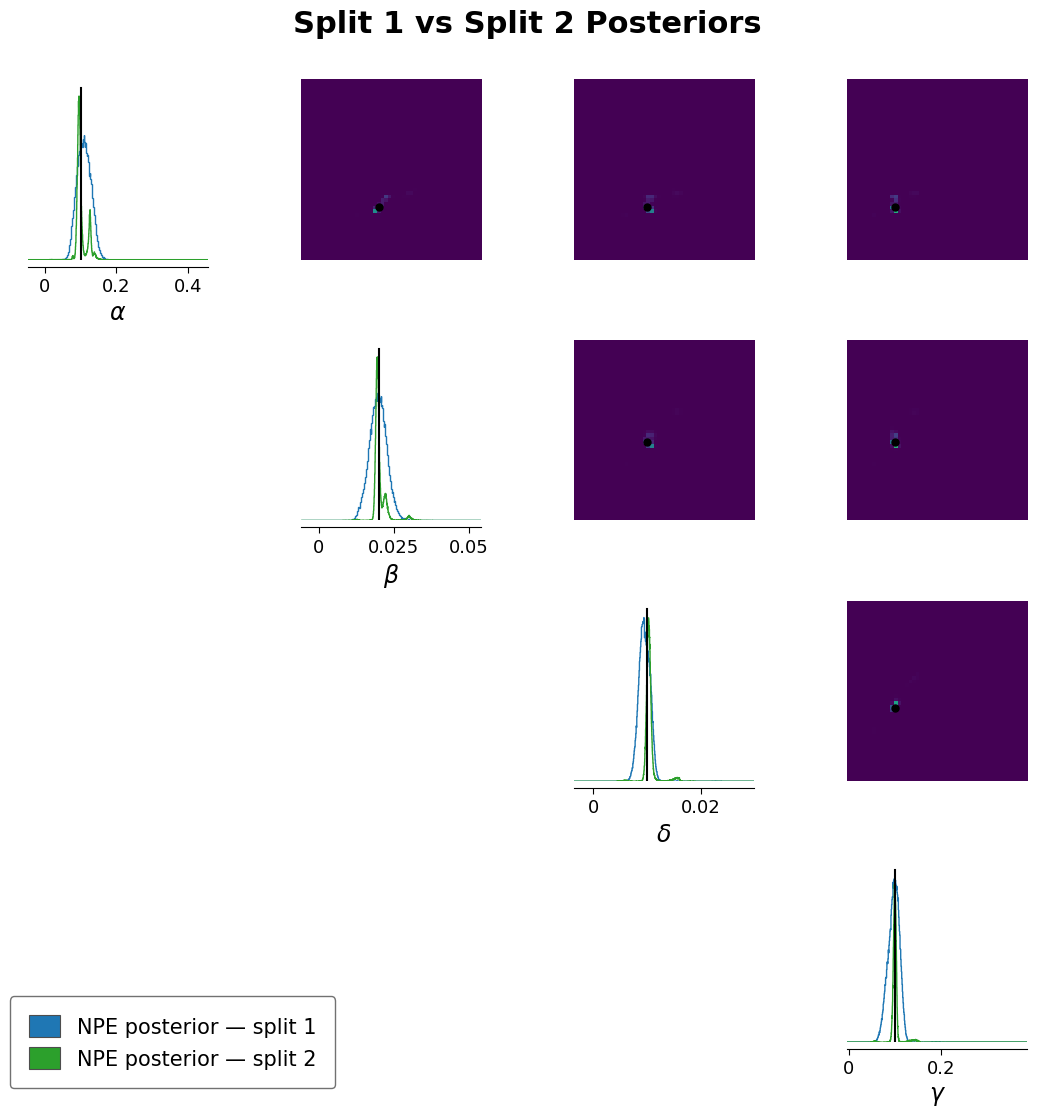

In [5]:
# ============================================================
# Presentation-quality pairplots — sbi.pairplot version
# (Lotka-Volterra has no closed-form Fisher information; we just
#  show prior shrinkage and the null vs perturbed posteriors.)
# ============================================================

import matplotlib as mpl
import matplotlib.patches as mpatches

_RC = {
    "font.size":       16,
    "axes.labelsize":  18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titlesize":  16,
}

LV_PARAM_LABELS = [r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]


def _style_axes(axes):
    for row in axes:
        for ax in row:
            if ax is None:
                continue
            ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
            ax.xaxis.label.set_size(17)
            ax.yaxis.label.set_size(17)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)


def _add_legend(fig, entries):
    handles = [mpatches.Patch(facecolor=c, edgecolor="0.3", linewidth=0.8, label=lbl)
               for c, lbl in entries]
    leg = fig.legend(
        handles=handles, fontsize=15, frameon=True,
        facecolor="white", edgecolor="0.3",
        loc="lower left", bbox_to_anchor=(0.02, 0.02),
        borderpad=0.9, handlelength=1.5, handleheight=1.2,
    )
    leg.get_frame().set_linewidth(1.0)


def _to_tensor(s):
    if not torch.is_tensor(s):
        s = torch.tensor(np.asarray(s, dtype=np.float32))
    return s.clone().float()


def _empirical_limits(samples_list, pad_frac=0.05):
    arr = np.concatenate([s.numpy() if torch.is_tensor(s) else np.asarray(s, dtype=float)
                          for s in samples_list], axis=0)
    mn, mx = arr.min(axis=0), arr.max(axis=0)
    pad    = pad_frac * (mx - mn)
    return [[mn[i] - pad[i], mx[i] + pad[i]] for i in range(arr.shape[1])]


def plot_prior_vs_posteriors_lv(samples1, samples2, prior, true_parameters,
                                 systematic_label=None, n_prior_samples=50_000):
    """Prior vs both NPE posteriors. Limits set from prior support."""
    prior_samples = prior.sample((n_prior_samples,))
    prior_plot    = _to_tensor(prior_samples)
    post1_plot    = _to_tensor(samples1)
    post2_plot    = _to_tensor(samples2)

    true_plot = _to_tensor(np.asarray(true_parameters, dtype=float).reshape(1, -1)).squeeze(0)

    sys_label = systematic_label or "NPE posterior — split 2"

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[prior_plot, post1_plot, post2_plot],
            points=true_plot[None, :],
            limits=_empirical_limits([prior_plot]),
            figsize=(11, 11),
            labels=LV_PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "Prior"),
        ("#2ca02c", "NPE posterior — split 1"),
        ("#9467bd", sys_label),
    ])
    fig.suptitle("Prior vs Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_posteriors_overlaid_lv(samples1, samples2, true_parameters,
                                  systematic_label=None):
    """Just the two posteriors, tight limits."""
    post1_plot = _to_tensor(samples1)
    post2_plot = _to_tensor(samples2)

    true_plot = _to_tensor(np.asarray(true_parameters, dtype=float).reshape(1, -1)).squeeze(0)

    sys_label = systematic_label or "NPE posterior — split 2"

    tight_limits = _empirical_limits([post1_plot, post2_plot], pad_frac=0.15)

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot],
            points=true_plot[None, :],
            limits=tight_limits,
            figsize=(11, 11),
            labels=LV_PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — split 1"),
        ("#2ca02c", sys_label),
    ])
    fig.suptitle("Split 1 vs Split 2 Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_lv(
    samples1, samples2, prior1, true_parameters,
    systematic_label="NPE posterior — split 2",
)

plot_posteriors_overlaid_lv(
    samples1, samples2, true_parameters,
    systematic_label="NPE posterior — split 2",
)


Removed no burn in
Removed no burn in
Removed no burn in


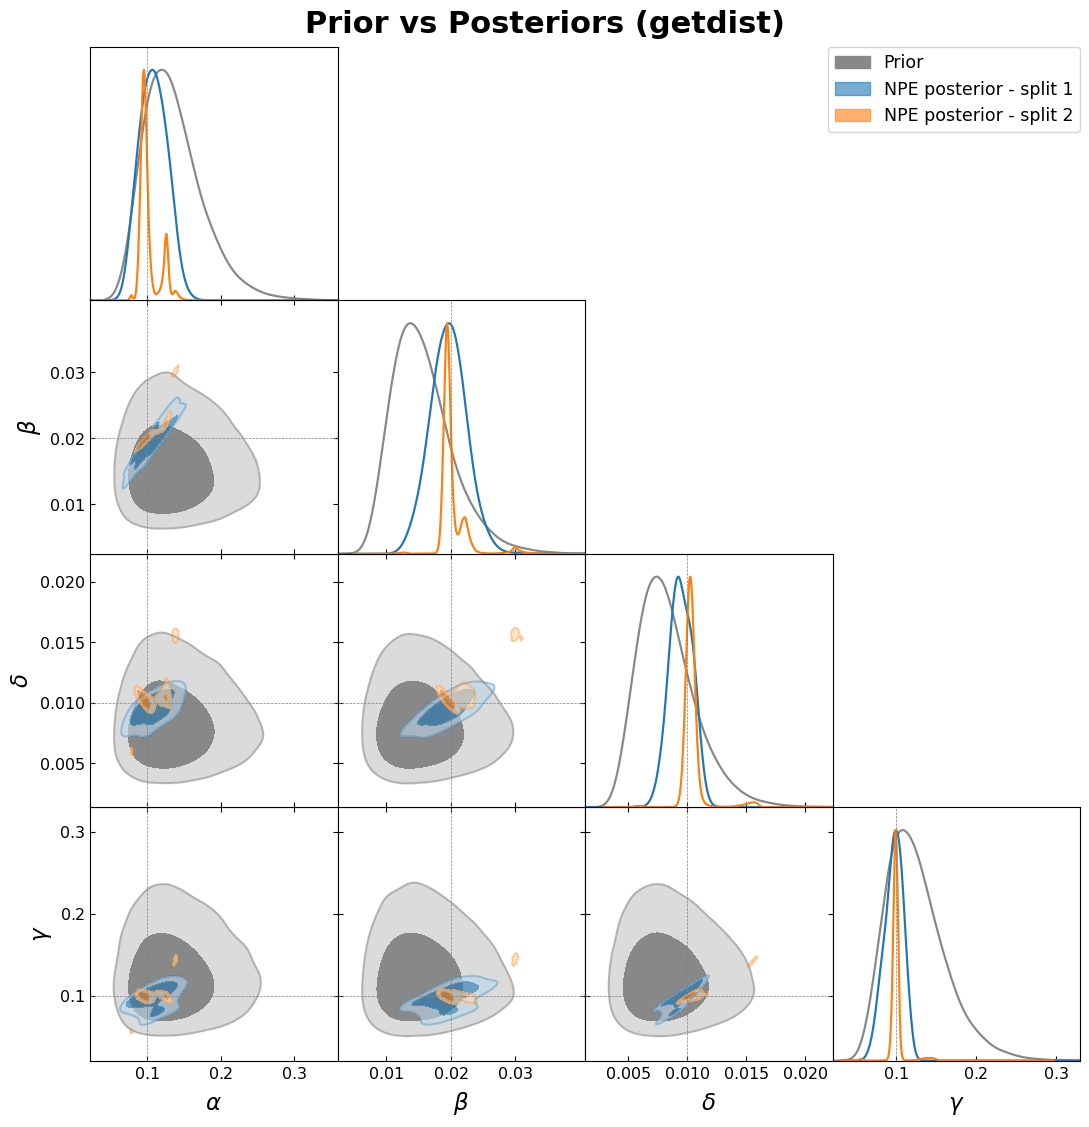

Removed no burn in
Removed no burn in


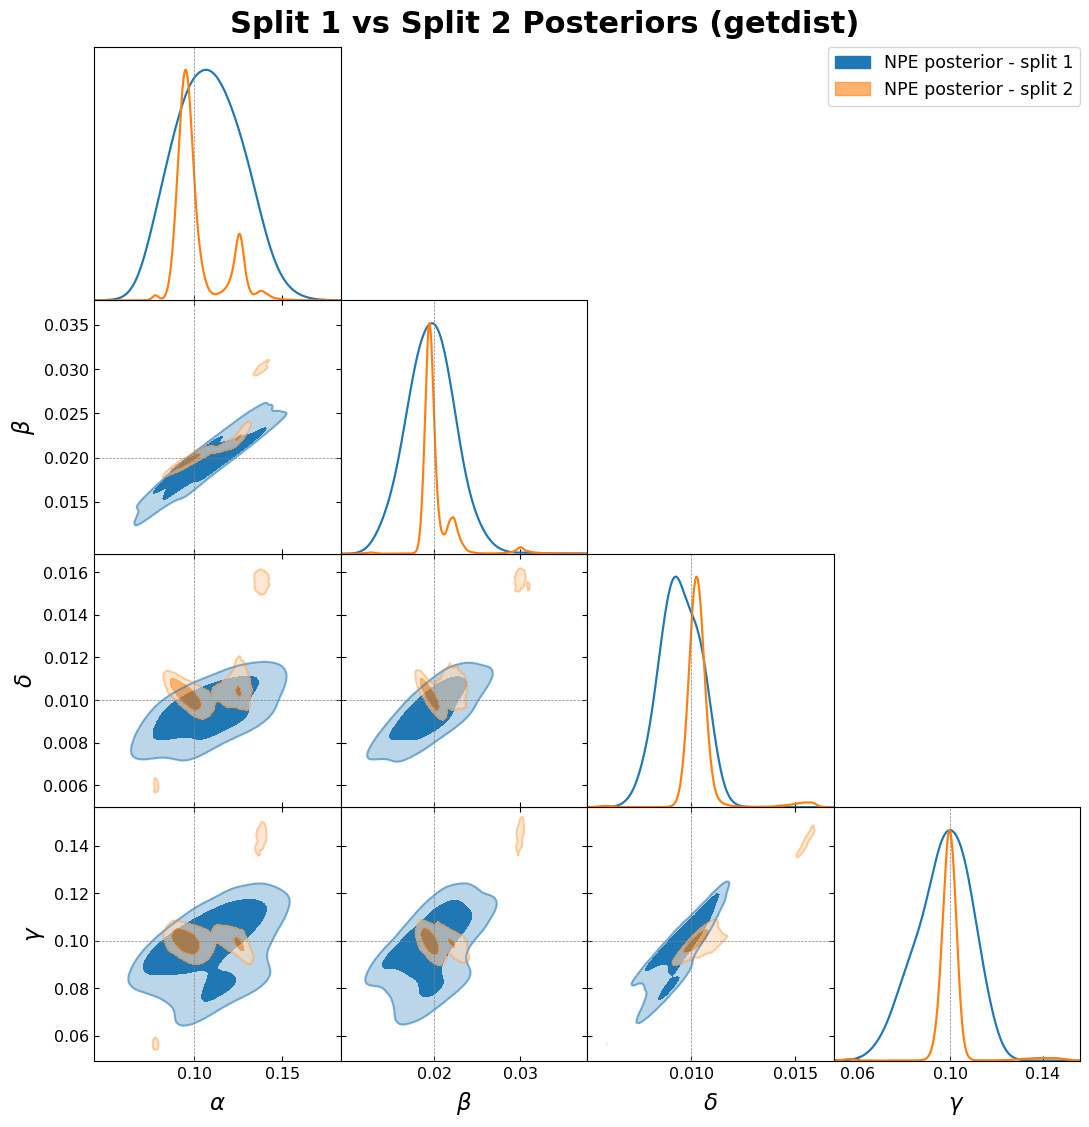

In [6]:
# ============================================================
# getdist versions (Will's Apr-14 ask)
# Peak=1 1D marginals so PDF shapes can be compared without sample bias.
# ============================================================

#%pip install --quiet getdist

from getdist import MCSamples, plots as gd_plots

LV_GD_NAMES  = ["alpha", "beta", "delta", "gamma"]
LV_GD_LABELS = [r"\alpha", r"\beta", r"\delta", r"\gamma"]


def _to_mcsamples_lv(samples, label):
    arr = samples.numpy() if torch.is_tensor(samples) else np.asarray(samples)
    arr = arr.astype(float).copy()
    return MCSamples(samples=arr, names=LV_GD_NAMES, labels=LV_GD_LABELS, label=label)


def _make_plotter_lv(width_inch=11):
    g = gd_plots.get_subplot_plotter(width_inch=width_inch)
    g.settings.norm_1d_density          = True
    g.settings.alpha_filled_add         = 0.6
    g.settings.axes_fontsize            = 13
    g.settings.lab_fontsize             = 18
    g.settings.legend_fontsize          = 14
    g.settings.linewidth                = 2.0
    g.settings.linewidth_contour        = 2.0
    g.settings.solid_contour_palefactor = 0.7
    return g


def _true_markers_lv(true_parameters):
    t = np.asarray(true_parameters, dtype=float).reshape(-1)
    return dict(zip(LV_GD_NAMES, t))


def plot_prior_vs_posteriors_lv_gd(samples1, samples2, prior, true_parameters,
                                    systematic_label=None, n_prior_samples=50_000):
    sys_label = systematic_label or "NPE posterior - split 2"
    mc_prior = _to_mcsamples_lv(prior.sample((n_prior_samples,)), "Prior")
    mc1      = _to_mcsamples_lv(samples1, "NPE posterior - split 1")
    mc2      = _to_mcsamples_lv(samples2, sys_label)

    g = _make_plotter_lv()
    g.triangle_plot(
        [mc_prior, mc1, mc2],
        filled=True,
        contour_colors=["#888888", "#1f77b4", "#ff7f0e"],
        markers=_true_markers_lv(true_parameters),
        legend_loc="upper right",
    )
    plt.suptitle("Prior vs Posteriors (getdist)", fontsize=22, fontweight="bold", y=1.02)
    plt.show()


def plot_posteriors_overlaid_lv_gd(samples1, samples2, true_parameters,
                                     systematic_label=None):
    sys_label = systematic_label or "NPE posterior - split 2"
    mc1 = _to_mcsamples_lv(samples1, "NPE posterior - split 1")
    mc2 = _to_mcsamples_lv(samples2, sys_label)

    g = _make_plotter_lv()
    g.triangle_plot(
        [mc1, mc2],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e"],
        markers=_true_markers_lv(true_parameters),
        legend_loc="upper right",
    )
    plt.suptitle("Split 1 vs Split 2 Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_lv_gd(
    samples1, samples2, prior1, true_parameters,
    systematic_label="NPE posterior - split 2",
)
plot_posteriors_overlaid_lv_gd(
    samples1, samples2, true_parameters,
    systematic_label="NPE posterior - split 2",
)


In [29]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error

In [30]:

dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct,
                                       x_obs1, x_obs2, n_theta=500)



In [ ]:

dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, posterior2_direct, prior1,
                                       100, 500, noise1, n_obs1, sigma_hare1, sigma_lynx1,
                                       obs1, split_type, t_span)
print("DKL observed:", dkl_obs)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def calibrate_null_dkl_neat(posterior1, posterior2, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span, dkl_obs):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 200 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i, split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) # obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PRESENTATION PLOTTING (Consistent Style)
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid behind the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label='Null Distribution ($H_0$)')
    
    # Vertical lines for Observed D_KL and Critical Value
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles: Fixed capitalization and added padding
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$ (Lotka-Volterra)", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend: Solid white background with a crisp border and slight shadow
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    # Automatically adjust layout so nothing gets cut off
    plt.tight_layout()
    plt.show()

    print(f"Null 95 percent critical value: {crit_val_95:.2f}")

    return dkls, crit_val_95

In [ ]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(
    posterior1_direct, posterior2_direct, prior1,
    2500, 500,
    noise1, n_obs1, sigma_hare1, sigma_lynx1,
    obs1, split_type, t_span, dkl_obs,
)


: 

: 

: 

: 

: 

In [ ]:

dkl_obs_2, std_obs_2, error_obs_2 = calc_dkl(posterior1_direct, posterior2_direct,
                                              x_obs1, x_obs2, n_theta=2500)


dkls_2, crit_val_95_2 = calibrate_null_dkl(posterior1_direct, posterior2_direct, prior1,
                                           200, 2500, noise1, n_obs1, sigma_hare1, sigma_lynx1,
                                           obs1, split_type, t_span)
print("DKL observed:", dkl_obs_2)


: 

: 

: 

: 

: 

In [ ]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]

# empty array to store values
mean_vals=[0]*len(N_theta_vals)
std_dev_vals = [0]*len(N_theta_vals)
error_vals = [0]*len(N_theta_vals)

# generate some random test data, following same process:
def generate_loop_data(prior,distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, 2*t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data
        return x1_i, x2_i

x1_loop, x2_loop = generate_loop_data(prior1, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)

for i in range(len(N_theta_vals)):
        n_theta = N_theta_vals[i]
        mean_vals[i], std_dev_vals[i], error_vals[i] = calc_dkl(posterior1_direct, posterior1_direct, x1_loop, x2_loop, n_theta = n_theta)
        print(i)



0
1
2
3
4


: 

: 

: 

: 

: 

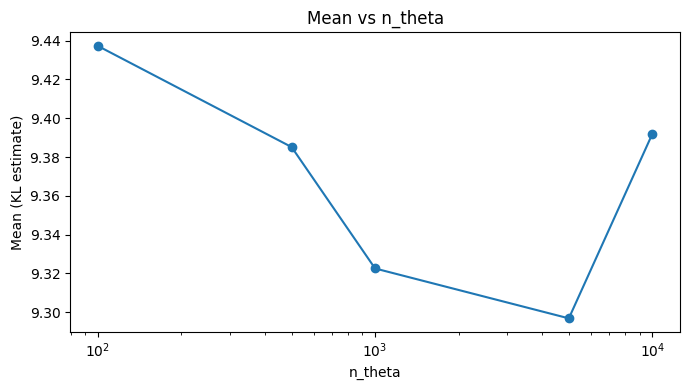

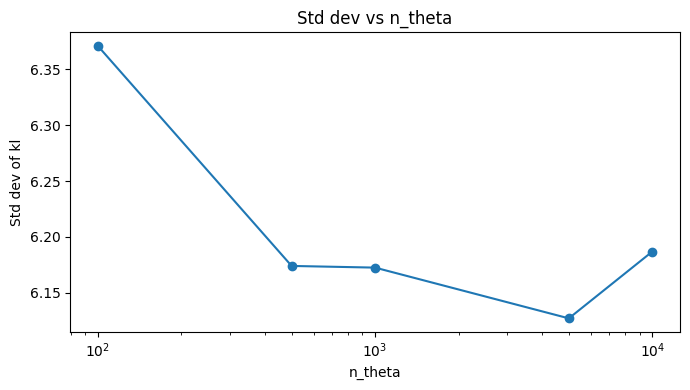

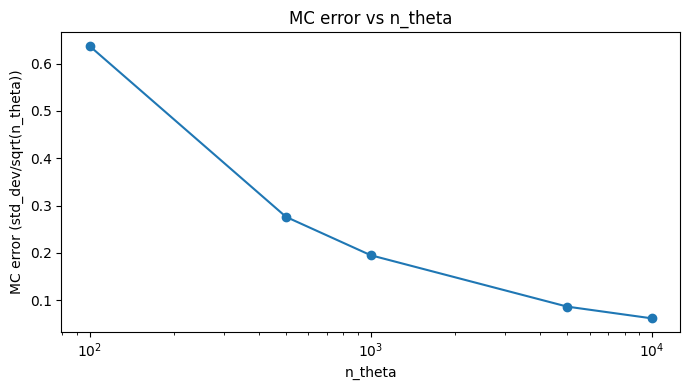

: 

: 

: 

: 

: 

In [ ]:

N_theta_vals = np.array(N_theta_vals, dtype=float)
mean_vals = np.array(mean_vals, dtype=float)
std_dev_vals = np.array(std_dev_vals, dtype=float)
error_vals = np.array(error_vals, dtype=float)

# Plot mean
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, mean_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Mean (KL estimate)")
plt.title("Mean vs n_theta")
plt.tight_layout()
plt.show()

# 2) Std dev vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, std_dev_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("Std dev of kl")
plt.title("Std dev vs n_theta")
plt.tight_layout()
plt.show()

# 3) Error vs N_theta
plt.figure(figsize=(7, 4))
plt.xscale("log")
plt.plot(N_theta_vals, error_vals, marker="o")
plt.xlabel("n_theta")
plt.ylabel("MC error (std_dev/sqrt(n_theta))")
plt.title("MC error vs n_theta")
plt.tight_layout()
plt.show()









In [35]:
# ============================================================
# === Refactored Sweep Helpers (2026-05-06, applies to LV) ===
# Split null calibration (high N, once) from perturbed sweep (low N, per α).
# Both parallelised using joblib. Null is α-independent; perturbed is per-α.
# This pattern cuts compute by ~50% vs recomputing null at every multiplier.
#
# === CHANGE (2026-05-07): split-aware calibration generator ===
# Previously, calibration always simulated 2*t_span from obs1[0]=(40,9) and
# split. For 'first_second' this produced split-2 data starting from theta_i's
# evolved state at t=t_span — but training (LV_KL_Calibrate) starts split-2
# simulations from obs2[0] (the truth's state at t=t_span). The mismatch made
# split-2 calibration data OOD wrt the trained NPE, causing catastrophic
# leakage (>99% of posterior mass outside the prior) and slow log_prob calls.
#
# New behaviour: calibration mirrors training exactly.
#   - 'first_second': each split simulated independently (y0 = obs1[0] for
#     split 1, y0 = obs2[0] for split 2), each over t_span — identical to
#     how x1 / x2 were generated in LV_KL_Calibrate.
#   - 'even_odd': single 2*t_span trajectory from obs1[0], then even/odd
#     split — unchanged (training also used a (40,9)-rooted trajectory).
#
# === CHANGE (2026-05-07b): perturb split 2, not split 1 ===
# The systematic story is "detector change at t=t_span, increasing observed
# counts" — that affects observations AFTER t=t_span, i.e. split 2 (the
# second half). Previously we were scaling split 1, which corresponds to
# "split 1 detector miscalibrated" — a different (and physically less
# motivated) systematic. The multiplier is now applied to traj2's predator
# column; split 1 is drawn null.
# ============================================================

def _gen_split_data(theta_i, noise_train, split_type, t_span,
                    n_obs1, sigma_hare1, sigma_lynx1, obs1,
                    n_obs2, sigma_hare2, sigma_lynx2, obs2):
    """Generate (traj1, traj2) calibration data that match the training
    distribution of each NPE."""
    if split_type == 'first_second':
        traj1 = simulator_distribution(noise_train, theta_i, n_obs1,
                                        sigma_hare1, sigma_lynx1, obs1, t_span)
        traj2 = simulator_distribution(noise_train, theta_i, n_obs2,
                                        sigma_hare2, sigma_lynx2, obs2, t_span)
        return traj1, traj2
    elif split_type == 'even_odd':
        traj_full = simulator_distribution(noise_train, theta_i,
                                            n_obs1 + n_obs2,
                                            sigma_hare1, sigma_lynx1,
                                            obs1, 2 * t_span)
        return choose_splitter(traj_full, split_type)
    else:
        raise ValueError(f"Unknown split type: {split_type}")


def calibrate_null_dkl_only(posterior1, posterior2, prior, N, n_theta,
                             noise_train,
                             n_obs1, sigma_hare1, sigma_lynx1, obs1,
                             n_obs2, sigma_hare2, sigma_lynx2, obs2,
                             split_type, t_span, n_jobs=-1):
    """Null distribution of D_KL: same noise model on both splits, no systematic.
    Run ONCE at high N (e.g. 1000-2000) for a tight 95th percentile.
    Parallelised."""

    def _one_null_realisation(i):
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        traj1, traj2 = _gen_split_data(theta_i, noise_train, split_type, t_span,
                                        n_obs1, sigma_hare1, sigma_lynx1, obs1,
                                        n_obs2, sigma_hare2, sigma_lynx2, obs2)
        x1_i = summarize_simulation(traj1)
        x2_i = summarize_simulation(traj2)
        return calc_dkl(posterior1, posterior2, x1_i, x2_i, n_theta=n_theta)[0]

    dkls = np.asarray(Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(_one_null_realisation)(i) for i in range(N)
    ))
    crit_val_95 = float(np.quantile(dkls, 0.95))
    return dkls, crit_val_95


def calibrate_perturb_dkl_only(posterior1, posterior2, prior, N, n_theta,
                                noise_train,
                                n_obs1, sigma_hare1, sigma_lynx1, obs1,
                                n_obs2, sigma_hare2, sigma_lynx2, obs2,
                                split_type, t_span,
                                multiplier=1.05, n_jobs=-1):
    """Perturbed D_KL distribution at a fixed multiplier.
    Split-2 obs uses multiplier-scaled predator column (detector change at
    t=t_span affects observations AFTER t_span); split-1 is null.
    Lower N (e.g. 200-300) is fine — only median matters.
    Parallelised."""

    def _one_perturb_realisation(i):
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()

        # Null split-1 (training-distribution): independent draw, no systematic.
        traj1, _ = _gen_split_data(theta_i, noise_train, split_type, t_span,
                                    n_obs1, sigma_hare1, sigma_lynx1, obs1,
                                    n_obs2, sigma_hare2, sigma_lynx2, obs2)
        x1_i = summarize_simulation(traj1)

        # Perturbed split-2: independent draw, predator (column 1) scaled.
        # Represents the detector-change-at-t_span systematic.
        _, traj2_pert = _gen_split_data(theta_i, noise_train, split_type, t_span,
                                         n_obs1, sigma_hare1, sigma_lynx1, obs1,
                                         n_obs2, sigma_hare2, sigma_lynx2, obs2)
        traj2_pert = traj2_pert.copy().astype(float)
        traj2_pert[:, 1] *= multiplier
        x2_i_perturbed = summarize_simulation(traj2_pert)

        return calc_dkl(posterior1, posterior2, x1_i, x2_i_perturbed, n_theta=n_theta)[0]

    dkls_p = np.asarray(Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(_one_perturb_realisation)(i) for i in range(N)
    ))
    median_perturbed = float(np.median(dkls_p))
    return dkls_p, median_perturbed


In [43]:
# === Updated call using refactored helpers ===
# Null is computed once at high N (1000); perturbed sweep at lower N (300) per multiplier.
# Only Option A: predator-only multiplier sweep (no Option B noise_swap).

N_null      = 500

n_theta_sw  = 500

print("--- Computing null distribution (run once) ---")
dkls_null_sw, crit_val_95_sw = calibrate_null_dkl_only(
    posterior1_direct, posterior2_direct, prior1,
    N_null, n_theta_sw,
    noise_train,
    n_obs1, sigma_hare1, sigma_lynx1, obs1,
    n_obs2, sigma_hare2, sigma_lynx2, obs2,
    split_type, t_span,
)
print(f"Null 95% critical value: {crit_val_95_sw:.3f}")


--- Computing null distribution (run once) ---


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 354 tasks      | elapsed:   18.2s


Null 95% critical value: 47.492


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   25.4s finished


In [51]:
N_pert      = 1000
# Predator multiplier sweep
multipliers_to_test = [1.46]
sweep_results = {}

for m in multipliers_to_test:
    print(f"\n--- Predator multiplier = {m} ---")
    dkls_p, median_p = calibrate_perturb_dkl_only(
        posterior1_direct, posterior2_direct, prior1,
        N_pert, n_theta_sw,
        noise_train,
        n_obs1, sigma_hare1, sigma_lynx1, obs1,
        n_obs2, sigma_hare2, sigma_lynx2, obs2,
        split_type, t_span,
        multiplier=m,
    )
    detected = median_p >= crit_val_95_sw
    sweep_results[m] = (dkls_p, median_p, detected)
    print(f"  median perturbed D_KL = {median_p:.3f}  |  detected = {detected}")

print("\n--- Predator Multiplier Sweep Summary ---")
for m, (_, med, det) in sweep_results.items():
    flag = "DETECTED" if det else "  not   "
    print(f"  multiplier={m:.4f}   median D_KL={med:.3f}   {flag}")


--- Predator multiplier = 1.46 ---


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 354 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 704 tasks      | elapsed:   36.0s


  median perturbed D_KL = 47.624  |  detected = True

--- Predator Multiplier Sweep Summary ---
  multiplier=1.4600   median D_KL=47.624   DETECTED


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   51.3s finished


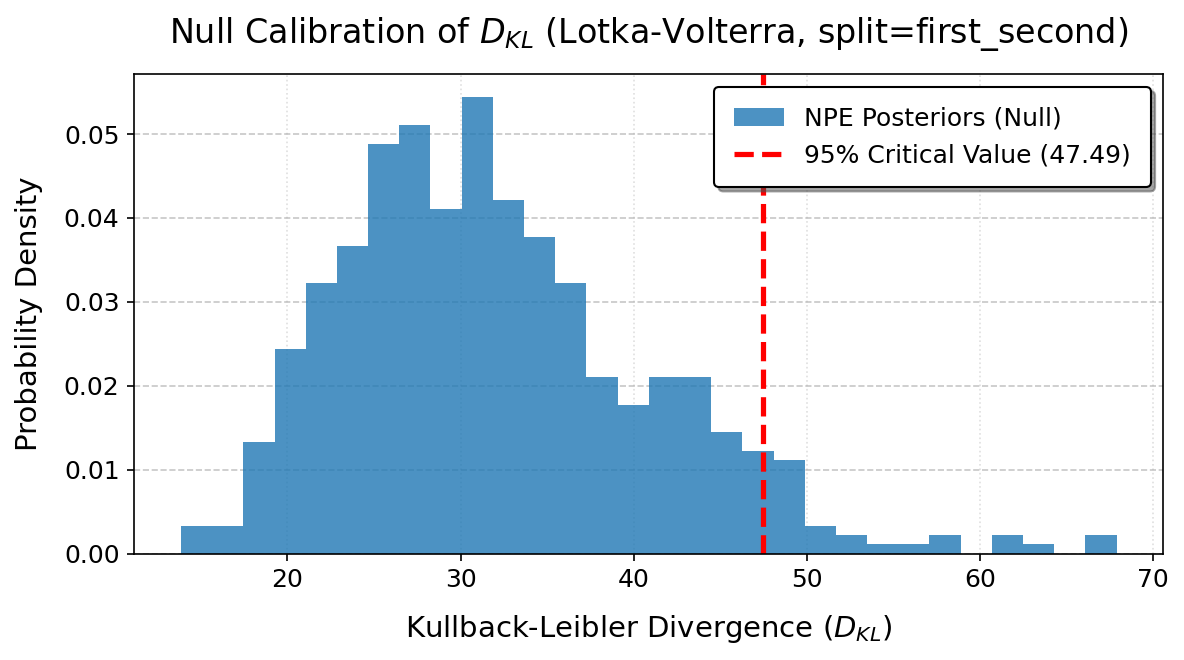

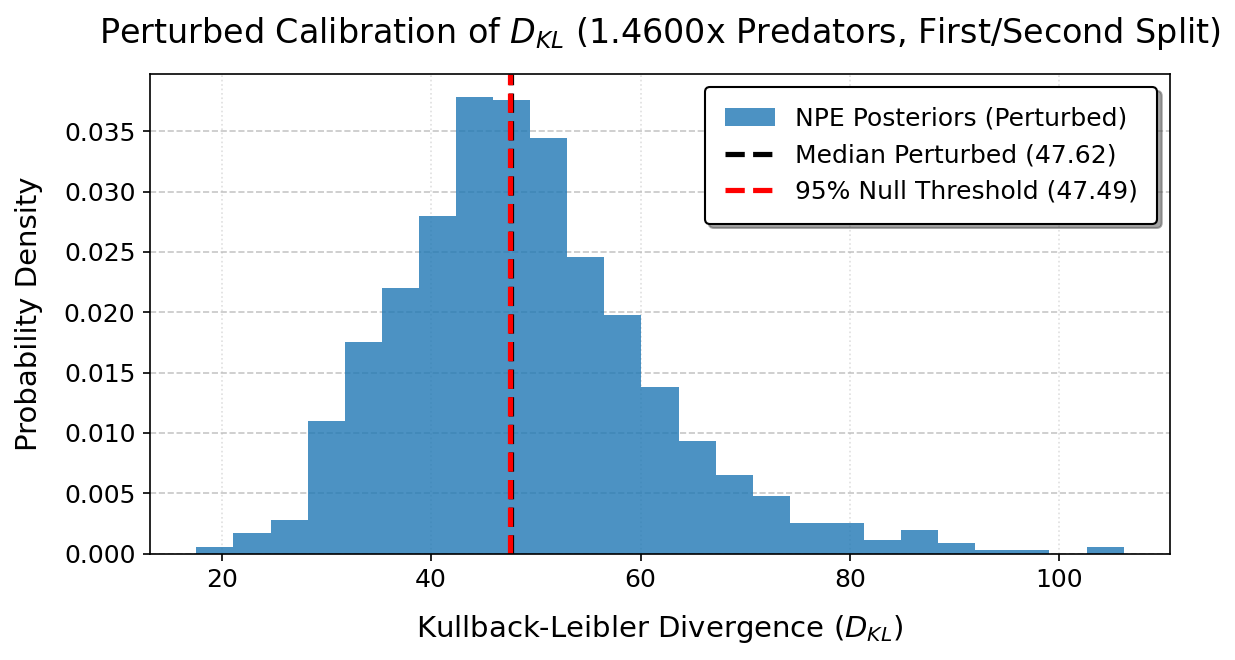


Null 95% critical value:      47.49
Perturbed 95% critical value: 71.28


In [53]:
# ============================================================
# Null Calibration Histogram
# ============================================================
plt.figure(figsize=(8, 4.5), dpi=150)

plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4)

plt.hist(dkls_null_sw, bins=30, density=True, color='tab:blue', 
         label='NPE Posteriors (Null)', alpha=0.8)

plt.axvline(crit_val_95_sw, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Critical Value ({crit_val_95_sw:.2f})')

plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(rf"Null Calibration of $D_{{KL}}$ (Lotka-Volterra, split={split_type})", 
          fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', 
           edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# ============================================================
# Perturbed Calibration Histogram (at detection threshold)
# ============================================================
# Get the last multiplier tested
last_multiplier = sorted(sweep_results.keys())[-1]
dkls_p, median_p, detected = sweep_results[last_multiplier]

plt.figure(figsize=(8, 4.5), dpi=150)

plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4)

plt.hist(dkls_p, bins=25, density=True, color='tab:blue', 
         label='NPE Posteriors (Perturbed)', alpha=0.8)

plt.axvline(median_p, color='black', linestyle='--', linewidth=2.5, 
            label=f'Median Perturbed ({median_p:.2f})')

plt.axvline(crit_val_95_sw, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Null Threshold ({crit_val_95_sw:.2f})')



plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(rf"Perturbed Calibration of $D_{{KL}}$ ({last_multiplier:.4f}x Predators, First/Second Split)", 
          fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', 
           edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# ============================================================
# Summary
# ============================================================
print(f"\nNull 95% critical value:      {crit_val_95_sw:.2f}")
print(f"Perturbed 95% critical value: {float(np.quantile(dkls_p, 0.95)):.2f}")

: 

: 

: 

: 

: 